# 최종 미션 — 파이썬 재현 노트북
파일명을 `미션재현_이름.ipynb`로 바꾸고 시작하세요.

## 이 노트북의 사용법 ⚠️ 중요

**코드는 여러분이 직접 씁니다.** 주석으로 "무엇을 해야 하는지"만 안내되어 있습니다.

```python
# [해야 할 일] 결측이 몇 개인지 확인
# [힌트] 표의 정보를 요약해주는 메서드 (교재 2-3장)
# [결과] 어떤 컬럼에 몇 개인지 보여야 함

여기에 코드 작성  ← 이 자리를 채우는 게 여러분의 일
```

### ⚠️ 미션은 스스로 수행합니다

**코드 작성과 분석 판단은 질문 대상이 아닙니다.** 오늘은 심사가 진행되는 날이며, 이 부분이 평가 대상입니다.

| 구분 | 질문 가능 여부 |
|---|---|
| 미션 요구사항·제출 형식이 이해되지 않을 때 | ✅ 질문 가능 |
| 데이터 컬럼의 의미가 이해되지 않을 때 | ✅ 질문 가능 |
| 실행 환경 오류 (파일 업로드, Colab 접속 등) | ✅ 질문 가능 |
| **코드를 어떻게 쓰는지** | ❌ 스스로 해결 |
| **어떤 그래프를 골라야 하는지** | ❌ 스스로 판단 |
| **기준값을 얼마로 정해야 하는지** | ❌ 스스로 판단 |
| **문법 오류·에러 해결** | ❌ 스스로 해결 |

**막혔을 때 찾아볼 자료** (전부 배포되어 있습니다)

| 상황 | 참조 |
|---|---|
| Orange3로는 했는데 코드를 모르겠다 | 교재 **4-9 로제타석** (Orange3 ↔ 파이썬 대응표) |
| 문법이 기억 안 난다 | 교재 **2장** (pandas 4동작) / 어제 실습 노트북 |
| 위젯 조작이 기억 안 난다 | Orange3 매뉴얼 **STEP 1~16** |
| 분석 흐름이 막막하다 | 어제 저녁 관찰 노트북 **Q1~Q6** |

> 💡 **한 번에 완성하려 하지 마세요.** 한 줄 쓰고 실행 → 결과 보고 → 다음 줄. 에러는 정상이며, 에러를 읽고 고치는 것도 평가 대상입니다.

### 📚 출처 메모 (NASA 저장소에서 확인한 내용을 여기에)
```
어떤 실험인가: 리튬이온 배터리 4개(#5, 6, 7, 18)를 상온에서 충전(CC-CV), 방전(CC), 임피던스 측정을 반복하여 초기 용량(2Ah) 대비 30% 감소(1.4Ah, EOL)할 때까지 노화시킨 실험
제공 기관: NASA Ames Research Center (Prognostics Center of Excellence, PCoE)
Citation: B. Saha and K. Goebel (2007). “Battery Data Set”, NASA Prognostics Data Repository, NASA Ames Research Center, Moffett Field, CA
원본 형식 → 배포 형식: MATLAB(.mat) 파일 → 분석에 필요한 스칼라값만 추출한 2차원 데이터 형태의 CSV 파일
```

---
## 준비 — 데이터 불러오기
> 이 셀만 완성되어 있습니다. 나머지는 직접 작성하세요.
> 시작 전: 왼쪽 📁 패널에 `battery_M.csv`와 `battery_NASA.csv`를 모두 드래그 업로드!

In [145]:
import pandas as pd
import matplotlib.pyplot as plt

m = pd.read_csv("/content/battery_M_260722.csv")          # PART 1 · 스냅샷
nasa = pd.read_csv("/content/battery_NASA_260722.csv")    # PART 2 · 시계열

print("M   :", m.shape, "  한 행 = 셀 하나")
print("NASA:", nasa.shape, "  한 행 = 셀 하나의 한 사이클")

M   : (30, 9)   한 행 = 셀 하나
NASA: (636, 11)   한 행 = 셀 하나의 한 사이클


---
# PART 1 — M데이터 (스냅샷)
## 필수 재현 ① · 데이터 확인
> Orange3의 **Column Statistics**로 본 것을 코드로 다시 확인합니다.

In [146]:
# ─────────────────────────────────────────────
# [해야 할 일] 데이터의 앞부분을 눈으로 확인
m.head()
# [힌트] 표의 첫 몇 줄만 보여주는 메서드
# ─────────────────────────────────────────────


,cell_id,cycle_count,initial_capacity,current_capacity,soh,internal_resistance,avg_temp,charge_time,batch_no
0,M01,725,2808.1,2583.5,92.0,32.6,30.1,93,2
1,M02,776,2782.8,2379.3,85.5,38.4,32.5,123,1
2,M03,243,2799.5,2617.5,93.5,39.5,27.1,109,2
3,M04,597,2811.9,2266.4,80.6,42.9,33.9,113,1
4,M05,210,2751.7,2724.2,99.0,28.9,27.2,97,3


In [147]:
# ─────────────────────────────────────────────
# [해야 할 일] 각 컬럼의 타입과 결측(Non-Null) 개수 확인
m.info()
# [힌트] "출석부 훑기" — 교재 2-3장의 세 버튼 중 두 번째
# [결과] 어떤 컬럼에 결측이 몇 개인지 알 수 있어야 함
# ─────────────────────────────────────────────


# ✏️ 확인한 내용 (발표 3·4장 재료): current_capacity에서 결측 컬럼이 3개 관측된다
#    결측 컬럼:   current_capacity     개수: 3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              30 non-null     object 
 1   cycle_count          30 non-null     int64  
 2   initial_capacity     30 non-null     float64
 3   current_capacity     27 non-null     float64
 4   soh                  30 non-null     float64
 5   internal_resistance  30 non-null     float64
 6   avg_temp             30 non-null     float64
 7   charge_time          30 non-null     int64  
 8   batch_no             30 non-null     int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 2.2+ KB


In [148]:
# ─────────────────────────────────────────────
# [해야 할 일] 수치 컬럼의 요약 통계로 이상한 값 찾기
print(m['soh'] <= 100 )
m[m['soh'] > 100][['cell_id', 'soh']]
# [힌트] 세 버튼 중 세 번째. min/max를 유심히 볼 것
# [결과] 물리적으로 불가능한 값이 눈에 띄어야 함
# ─────────────────────────────────────────────


# ✏️ 이상치: 컬럼 11  값  121  왜 불가능한가:
# ( current capacity / initial capacity ) * 100의 계산식에서
# soh는 100 이상일 수 없다.


0      True
1      True
2      True
3      True
4      True
5      True
6      True
7      True
8      True
9      True
10     True
11    False
12     True
13     True
14     True
15     True
16     True
17     True
18     True
19     True
20     True
21     True
22     True
23     True
24     True
25     True
26     True
27     True
28     True
29     True
Name: soh, dtype: bool


,cell_id,soh
11,M12,121.0


In [149]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 제외한 데이터를 m_clean 이라는 이름으로 만들기
# [힌트] 조건을 걸어 골라내기 = 마스킹 (교재 1-5, 2-5장)
#        SOH는 100%를 넘을 수 없다
# [결과] print로 제거 전/후 행 수를 비교해 보세요
# ─────────────────────────────────────────────
# M12는 기록된 SOH와 용량으로 계산한 SOH가 크게 불일치하므로 제외
m_clean = m[m["soh"] <= 100].copy()
print("제거 전:", m.shape)
print("제거 후:", m_clean.shape)



제거 전: (30, 9)
제거 후: (29, 9)


## 필수 재현 ② · 최종 판정
> Orange3의 **Select Rows**로 한 선별을 코드로 재현합니다. **두 결과가 같아야 정상입니다.**

In [150]:
# ─────────────────────────────────────────────
# [해야 할 일] 내가 Orange3에서 정한 기준을 조건으로 옮겨 최종 셀 선별
# [힌트] 조건이 2개 이상이면 각각 괄호로 감싸고 & 로 연결
#        df[(조건1) & (조건2)]  ← 괄호 빠뜨리면 에러 (오늘의 1등 에러)
# [결과] 선별된 셀 수를 출력하고, cell_id와 soh를 확인
# ─────────────────────────────────────────────
final = m_clean[(m_clean['soh'] <= 100)]
print(f"선별된 셀 수: {final['soh'].count()} 개")
final[['cell_id', 'soh']]



선별된 셀 수: 29 개


,cell_id,soh
0,M01,92.0
1,M02,85.5
2,M03,93.5
3,M04,80.6
4,M05,99.0
5,M06,87.3
6,M07,98.2
7,M08,99.0
8,M09,96.4
9,M10,83.1


In [151]:
# ─────────────────────────────────────────────
# [해야 할 일] Orange3 결과와 일치하는지 대조
# ─────────────────────────────────────────────
# ✏️ Orange3 Select Rows의 Data Out 셀 수:  29  개
# ✏️ 파이썬 len(final):  29  개
# ✏️ 일치? 예
#    → 아니오라면: 부등호 방향(>= vs >), 기준값, 조건 개수를 하나씩 대조해 보세요


---
# 관문 ① · 기준 민감도 ★변별
### "그 기준, 흔들리면 결과가 얼마나 달라지나요?"

기준값 하나로 판정하고 끝내면 평범합니다. **기준이 얼마나 예민한지 수치로** 보여주세요.

In [152]:
# ─────────────────────────────────────────────
# [해야 할 일] 내 기준값을 -3 / 그대로 / +3 으로 바꿔가며
#              각각 몇 개가 통과하는지 표처럼 출력
#
# [생각해볼 것] 같은 코드를 값만 바꿔 3번 쓰는 것보다,
#               값 목록을 만들어 반복시키는 게 낫지 않을까?
#               (어제 배운 for문 — 리스트를 하나씩 꺼내 쓰기)
#
# [결과 예시]
#   soh >= 82: 통과 26개 / 탈락 3개
#   soh >= 85: 통과 24개 / 탈락 5개
#   soh >= 88: 통과 22개 / 탈락 7개
# ─────────────────────────────────────────────
print("B 문항을 선택했기 때문에 기준값을 설정할 필요가 없다고 여겨져 패스하겠습니다.")

# ✏️ 발표 7장 문장: "기준을 3%p 낮추면 __개가 더 통과합니다.
#                    그만큼 예민한 경계이므로 __를 근거로 __로 정했습니다"


B 문항을 선택했기 때문에 기준값을 설정할 필요가 없다고 여겨져 패스하겠습니다.


In [153]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 내 기준 경계에 아슬아슬하게 걸린 셀 찾기
# [힌트] 기준값 ±2 범위에 있는 셀만 골라내면 됩니다 (조건 2개)
# [왜?] "이 셀은 왜 탈락시켰나요?" 질문에 사례로 답할 수 있습니다
# ─────────────────────────────────────────────



---
# 관문 ② · 결측의 영향 ★변별
### "빈칸을 채운 게 답을 바꾸지 않았나요?"

결측을 평균으로 채우고 넘어가면 놓치는 게 있습니다.

In [154]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 결측이 있던 셀들이 어떤 값을 가졌는지 확인
# [힌트] 결측 여부를 판단하는 메서드가 있습니다 (NaN인가?)
#        그 결과를 마스킹 조건으로 쓰면 결측 행만 골라집니다
# ─────────────────────────────────────────────
# 방법 1: isna() 사용 (가장 추천!)
mask = m_clean['current_capacity'].isna()

missing_cells = m_clean[mask]

# [보고 싶은 것] 그 셀들의 cell_id, soh, internal_resistance
missing_cells[['cell_id', 'soh', 'internal_resistance']]

# ✏️ 결측 셀들의 SOH는 합격 경계 근처인가, 확실한 불합격인가?


,cell_id,soh,internal_resistance
5,M06,87.3,42.8
17,M18,85.1,41.5
26,M27,94.4,35.9


In [155]:
# ─────────────────────────────────────────────
# [해야 할 일 2] 결측을 두 가지 방식으로 처리하고 최종 판정을 비교
#   ⓐ 평균으로 채우기  → 내 기준 적용 → 몇 개 통과?
#   ⓑ 해당 행 제외하기 → 내 기준 적용 → 몇 개 통과?
#
# [힌트] 빈칸 채우기 / 빈칸 있는 행 버리기에 해당하는 메서드가 각각 있습니다
#        (교재 4-9 로제타석의 '결측 채우기' 행 참고)
#(a) 평균으로 채우기
mean = m_clean['current_capacity'].mean()
m_filled = m_clean.copy()
m_filled['current_capacity'] = m_filled['current_capacity'].fillna(mean)

m_dropped = m_clean.dropna(subset=['current_capacity'])

# [결과] 두 방식의 최종 셀 수를 나란히 출력
print(f"(a) 평균으로 채웠을 때 남은 셀 수: {m_filled.shape[0]}개")
print(f"(b) 결측 행을 지웠을 때 남은 셀 수: {m_dropped.shape[0]} 개")
# ─────────────────────────────────────────────
# 두 방식이 최종 분석(상관관계)에 미치는 영향 비교

#(a)의 경우
corr_filled = m_filled.drop(columns=['cell_id']).corr()['soh'].sort_values()

#(b)의 경우
corr_dropped = m_dropped.drop(columns=['cell_id']).corr()['soh'].sort_values()

#결과 비교
print("--(a) 평균 대체 시 상관계수 순위--")
print(corr_filled.round(2))
print("--(b) 결측 행 제거 시 상관계수 순위--")
print(corr_dropped.round(2))

# ✏️ 판정이 달라졌는가? 나는 어느 쪽을 택했고 왜인가:
# 평균 대체와 결측 행 제거를 비교한 결과,
# 내부저항-SOH 상관계수는 각각 -0.84, -0.85로
# 방향과 강도가 거의 동일하였다.
# 따라서 결측 처리 방식이 핵심 결론은 바꾸지 않는다는 것을 확인하였다.
# 최종적으로는 작은 표본에서 3개 행의 정보 손실을 줄이기 위해
# 평균 대체 방식을 선택하였다.

(a) 평균으로 채웠을 때 남은 셀 수: 29개
(b) 결측 행을 지웠을 때 남은 셀 수: 26 개
--(a) 평균 대체 시 상관계수 순위--
internal_resistance   -0.84
charge_time           -0.39
initial_capacity      -0.34
avg_temp              -0.34
cycle_count           -0.33
batch_no               0.60
current_capacity       0.94
soh                    1.00
Name: soh, dtype: float64
--(b) 결측 행 제거 시 상관계수 순위--
internal_resistance   -0.85
avg_temp              -0.44
charge_time           -0.39
initial_capacity      -0.37
cycle_count           -0.35
batch_no               0.71
current_capacity       0.99
soh                    1.00
Name: soh, dtype: float64


---
# 관문 ③ · 함정 회피 ★변별
### "상관 1위가 정말 원인인가요?"

이 데이터에는 **의도적으로 심어둔 함정**이 있습니다. 순위표만 보면 걸립니다.

In [156]:
# ─────────────────────────────────────────────
# [해야 할 일] 이상치를 "제거하기 전(m)"과 "제거한 후(m_clean)"의
#              SOH 상관 순위를 각각 구해서 비교
# 1. 이상치 제거 전 (원본 데이터 m)
corr_before = m.drop(columns=['cell_id']).corr()['soh'].sort_values()

# 2. 이상치 제거 후 (이상치 걸러낸 데이터 m_clean)
corr_after = m_clean.drop(columns=['cell_id']).corr()['soh'].sort_values()

# [결과] 두 순위표를 나란히 출력
print("── [이상치 제거 전 (m)] ──")
print(corr_before.round(2))

print("\n── [이상치 제거 후 (m_clean)] ──")
print(corr_after.round(2))
# [힌트] 상관은 corr() — 단, cell_id는 글자라 계산에서 빼야 합니다
#        특정 열을 빼는 방법: drop(columns=[...])
#        SOH 기준 순위만 보려면 결과에서 'soh' 열을 뽑고 정렬
# [결과] 두 순위표를 나란히 출력해 어떤 변수의 순위가 크게 움직였는지 확인
# ─────────────────────────────────────────────
# 이상치(soh=121%)를 제거하기 전 후 내부 저항과의 상관계수가 -0.45에서 -0.84까지 증가.
# 따라서 내부저항은 121% SOH를 제거했을 때
# 가장 강하고 물리적으로 해석 가능한 열화 신호이다.



── [이상치 제거 전 (m)] ──
internal_resistance   -0.45
charge_time           -0.26
avg_temp              -0.22
cycle_count           -0.21
initial_capacity       0.03
batch_no               0.41
current_capacity       0.68
soh                    1.00
Name: soh, dtype: float64

── [이상치 제거 후 (m_clean)] ──
internal_resistance   -0.84
charge_time           -0.39
initial_capacity      -0.34
avg_temp              -0.34
cycle_count           -0.33
batch_no               0.60
current_capacity       0.99
soh                    1.00
Name: soh, dtype: float64


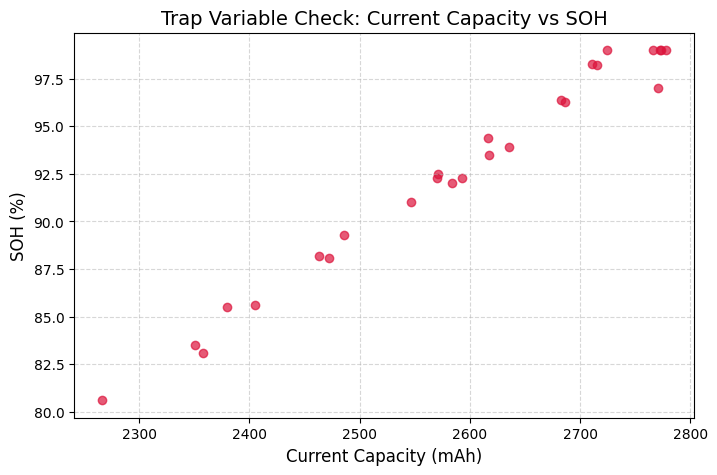

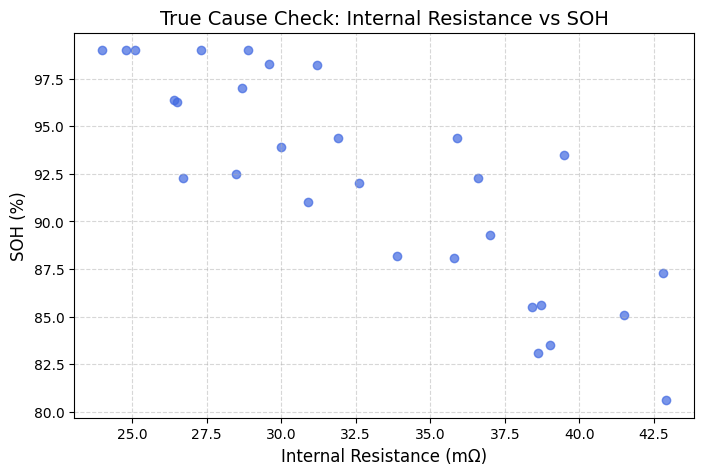

In [157]:
# ─────────────────────────────────────────────
# [해야 할 일] 의심스러운 변수를 산점도로 다시 확인
# [힌트] 산점도는 plot.scatter(x=..., y=...)
# [따져볼 것] 이 변수가 배터리를 늙게 할 "물리적 이유"가 있는가?
#             (예: 생산 배치 번호가 커지면 배터리가 빨리 늙는다? 말이 되는가?)
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

# 1. 함정 변수(current_capacity)와 SOH의 산점도 확인
# (용량이 줄어서 SOH가 감소한 게 아니라, SOH가 줄어들어 용량이 감소한 '결과'임을 시각적으로 증명)
plt.figure(figsize=(8, 5))
plt.scatter(m_clean['current_capacity'], m_clean['soh'], color='crimson', alpha=0.7)

plt.title('Trap Variable Check: Current Capacity vs SOH', fontsize=14)
plt.xlabel('Current Capacity (mAh)', fontsize=12)
plt.ylabel('SOH (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 2. 원인 변수(internal_resistance)와 SOH의 산점도 비교
plt.figure(figsize=(8, 5))
plt.scatter(m_clean['internal_resistance'], m_clean['soh'], color='royalblue', alpha=0.7)

plt.title('True Cause Check: Internal Resistance vs SOH', fontsize=14)
plt.xlabel('Internal Resistance (mΩ)', fontsize=12)
plt.ylabel('SOH (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ✏️ 상관 1위 변수:   current_capacity   물리적으로 타당한가? 타당하지 않다.
# soh = (current_capacity / initial capacity) * 100 으로 둘은 정의상 연결되어 있음.
# ✏️ 함정으로 의심되는 변수:  batch_no   배제 이유: 배치 넘버는 생산 그룹을 구분하는 범주형 식별값일 뿐.
# 배치 넘버의 숫자가 커지는 것은 soh와 물리적 상관관계가 전혀 없다.

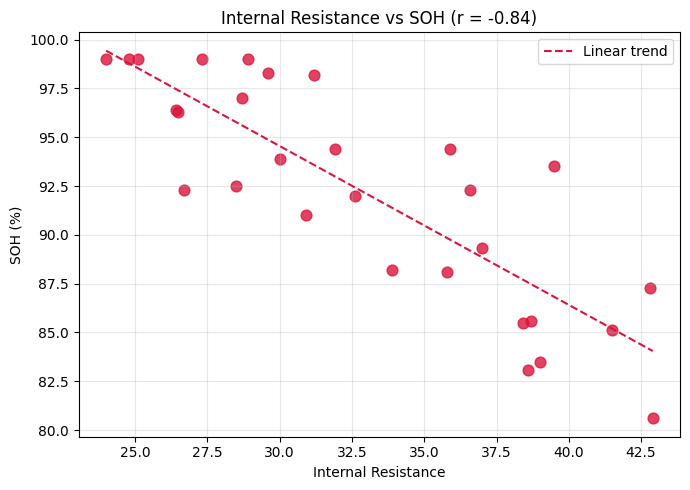

In [158]:
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 1. 내부저항과 SOH
# 물리적으로 타당한 열화 신호 확인
# =========================================================
plot_data = m_clean[["internal_resistance", "soh"]].dropna()

r = plot_data["internal_resistance"].corr(plot_data["soh"])

ax = plot_data.plot.scatter(
    x="internal_resistance",
    y="soh",
    figsize=(7, 5),
    s=60,
    alpha=0.8,
    color='crimson',
    title=f"Internal Resistance vs SOH (r = {r:.2f})"
)

# 추세선
x = plot_data["internal_resistance"]
y = plot_data["soh"]

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

ax.plot(
    x_line,
    slope * x_line + intercept,
    linestyle="--",
    color='crimson',
    label="Linear trend"
)

ax.set_xlabel("Internal Resistance")
ax.set_ylabel("SOH (%)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

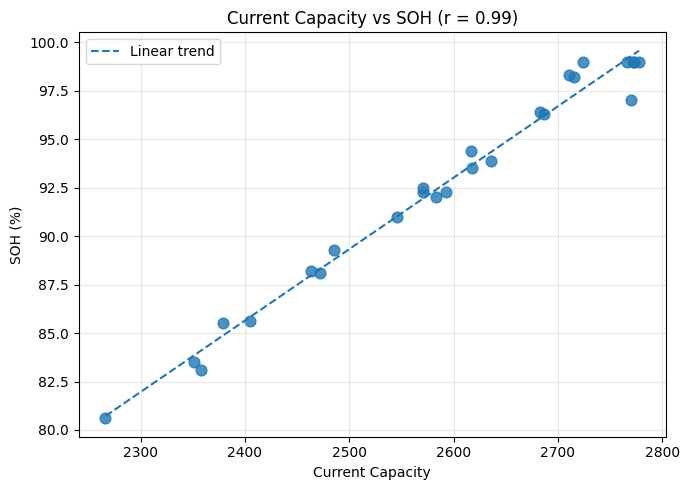

In [159]:
# =========================================================
# 2. 현재 용량과 SOH
# SOH 정의에 직접 포함되는 변수인지 확인
# =========================================================
plot_data = m_clean[["current_capacity", "soh"]].dropna()

r = plot_data["current_capacity"].corr(plot_data["soh"])

ax = plot_data.plot.scatter(
    x="current_capacity",
    y="soh",
    figsize=(7, 5),
    s=60,
    alpha=0.8,
    title=f"Current Capacity vs SOH (r = {r:.2f})"
)

# 추세선
x = plot_data["current_capacity"]
y = plot_data["soh"]

slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)

ax.plot(
    x_line,
    slope * x_line + intercept,
    linestyle="--",
    label="Linear trend"
)

ax.set_xlabel("Current Capacity")
ax.set_ylabel("SOH (%)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

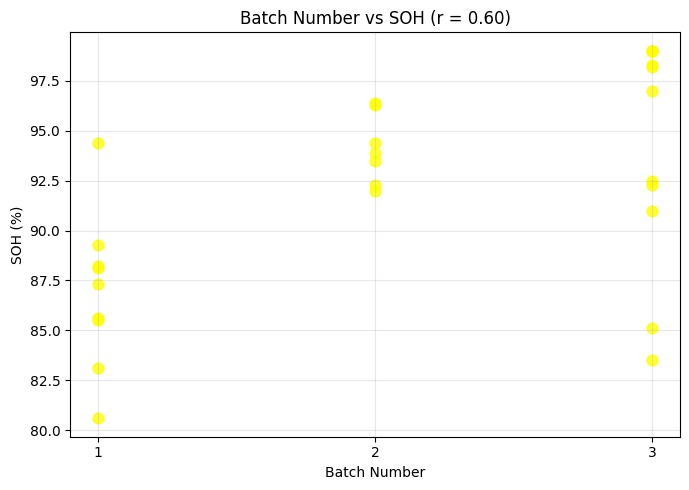

In [160]:
# =========================================================
# 3. 생산 배치 번호와 SOH
# 물리적 의미가 없는 함정 변수인지 확인
# =========================================================
plot_data = m_clean[["batch_no", "soh"]].dropna()

r = plot_data["batch_no"].corr(plot_data["soh"])

ax = plot_data.plot.scatter(
    x="batch_no",
    y="soh",
    figsize=(7, 5),
    s=60,
    alpha=0.8,
    color='yellow',
    title=f"Batch Number vs SOH (r = {r:.2f})"
)

# batch_no는 범주형 번호이므로 추세선을 그리지 않음
ax.set_xlabel("Batch Number")
ax.set_ylabel("SOH (%)")
ax.set_xticks(sorted(plot_data["batch_no"].unique()))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [161]:
# 해석
# 1. internal_resistance:
#    내부저항이 증가할수록 SOH가 감소하는 음의 관계가 나타난다.
#    배터리 열화에 따라 내부저항이 증가할 수 있으므로 물리적으로 타당하다.

# 2. current_capacity:
#    SOH와 매우 강한 양의 관계가 나타난다.
#    하지만 current_capacity는 SOH 계산에 직접 사용되므로
#    독립적인 열화 원인이라기보다 타깃 누수 또는 정의상 중복 변수이다.

# 3. batch_no:
#    상관계수는 비교적 크게 나타날 수 있지만 생산 배치를 구분하는 번호이다.
#    번호의 크기가 배터리 열화를 직접 유발한다는 물리적 근거가 없으므로
#    함정 변수로 판단한다.

---
# PART 2 — NASA 데이터 (시계열)
## 2단계 · 데이터 확인

In [162]:
# ─────────────────────────────────────────────
# [해야 할 일] NASA 데이터의 구조 파악 — 앞부분 + 결측 확인
# [주목] 결측이 있다면 어느 컬럼에, 몇 개나?
# ─────────────────────────────────────────────
import pandas as pd

#데이터 앞부분 확인
print("--데이터 앞부분--")
display(nasa.head())

#행렬 개수와 자료형 확인
print("--데이터 구조--")
print("데이터 크기:", nasa.shape)
nasa.info()

#컬럼별 결측값 개수 확인
print("--컬럼별 결측값 개수--")
missing_count = nasa.isna().sum()
print(missing_count)

#결측값이 있는 컬럼만 출력
print("--결측값이 있는 컬럼--")
print(missing_count[missing_count > 0])


--데이터 앞부분--


,cell_id,cycle_count,ambient_temp,capacity,soh,internal_resistance,avg_temp,max_temp,discharge_time,min_voltage,is_eol
0,B0005,1,24,1.8565,92.8,NaN,32.6,39.0,61.5,2.612,0
1,B0005,2,24,1.8463,92.3,NaN,32.7,39.0,61.2,2.587,0
2,B0005,3,24,1.8353,91.8,NaN,32.6,38.8,60.9,2.652,0
3,B0005,4,24,1.8353,91.8,NaN,32.5,38.8,60.5,2.593,0
4,B0005,5,24,1.8346,91.7,NaN,32.4,38.7,60.5,2.547,0


--데이터 구조--
데이터 크기: (636, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cell_id              636 non-null    object 
 1   cycle_count          636 non-null    int64  
 2   ambient_temp         636 non-null    int64  
 3   capacity             636 non-null    float64
 4   soh                  636 non-null    float64
 5   internal_resistance  579 non-null    float64
 6   avg_temp             636 non-null    float64
 7   max_temp             636 non-null    float64
 8   discharge_time       636 non-null    float64
 9   min_voltage          636 non-null    float64
 10  is_eol               636 non-null    int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 54.8+ KB
--컬럼별 결측값 개수--
cell_id                 0
cycle_count             0
ambient_temp            0
capacity                0
soh                     0
internal

In [163]:
# ─────────────────────────────────────────────
# [해야 할 일 1] 셀마다 사이클 수가 다른지 확인
# [힌트] 셀별로 묶어서(groupby) 각 그룹의 최대 사이클을 보면 됩니다
# [왜?] 셀마다 관측 길이가 다르면 비교할 때 주의해야 합니다 (발표 '한계' 재료)
# ─────────────────────────────────────────────
# 셀별 최대 사이클 확인
max_cycles = nasa.groupby('cell_id')['cycle_count'].max().sort_values(ascending = False)

print("--셀별 최대 사이클--")
print(max_cycles)

# ─────────────────────────────────────────────
# [해야 할 일 2 · 관문② 심화] 결측이 어디에 있는지 확인 ★
# [힌트] 결측인 행만 골라낸 뒤, 셀별·사이클별로 어디에 몰려 있는지 보세요
#        (groupby로 묶어 min/max 사이클을 보면 구간이 드러납니다)
# [따져볼 것] 결측이 무작위인가, 특정 구간에 몰려 있는가?
#             몰려 있다면 평균으로 채우는 게 왜 위험한가?
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# 원본 데이터 다시 불러오기
nasa = pd.read_csv("battery_NASA_260722.csv")

# SOH는 100%를 초과하더라도 원본값 그대로 유지
# 내부저항 원본도 보존하고, 결측 보완용 새 컬럼 생성
nasa["internal_resistance_filled"] = nasa["internal_resistance"]

# 실제 측정값인지 추정값인지 구분하는 변수
nasa["ir_imputed"] = nasa["internal_resistance"].isna().astype(int)

# 셀별로 결측값 보완
for cell_id, cell_data in nasa.groupby("cell_id"):

    # 사이클 순서대로 정렬
    cell_data = cell_data.sort_values("cycle_count")

    # 내부저항 결측 위치
    missing_mask = cell_data["internal_resistance"].isna()

    if missing_mask.sum() > 0:

        # 초기 열화 추세를 반영하기 위해
        # 결측 이후 처음 관측된 20개의 내부저항 사용
        early_observed = (
            cell_data
            .dropna(subset=["internal_resistance"])
            .head(20)
        )

        # 내부저항 = 기울기 × cycle_count + 절편
        slope, intercept = np.polyfit(
            early_observed["cycle_count"],
            early_observed["internal_resistance"],
            1
        )

        # 초기 결측 사이클의 내부저항 추정
        predicted_resistance = (
            slope * cell_data.loc[missing_mask, "cycle_count"]
            + intercept
        )

        # 원래 데이터의 해당 위치에 추정값 입력
        nasa.loc[
            cell_data.index[missing_mask],
            "internal_resistance_filled"
        ] = predicted_resistance.values


# 결과 확인
print(
    "보완 전 내부저항 결측:",
    nasa["internal_resistance"].isna().sum()
)

print(
    "보완 후 내부저항 결측:",
    nasa["internal_resistance_filled"].isna().sum()
)

display(
    nasa[
        [
            "cell_id",
            "cycle_count",
            "soh",
            "internal_resistance",
            "internal_resistance_filled",
            "ir_imputed"
        ]
    ].head(25)
)

# ✏️ 결측 구간: B0005, B0006, B0007 셀의 초기 1~19 사이클 구간
# 평균 대체가 위험한 이유: 내부 저항은 사이클(시간)에 따라 변하는 시계열 변수이므로,
# 특정 구간에 몰려 있는 빈칸을 전체 평균으로 일괄 대체하면 초기 열화 추세(Trend)가 심각하게 왜곡됨.


--셀별 최대 사이클--
cell_id
B0005    168
B0006    168
B0007    168
B0018    132
Name: cycle_count, dtype: int64
보완 전 내부저항 결측: 57
보완 후 내부저항 결측: 0


,cell_id,cycle_count,soh,internal_resistance,internal_resistance_filled,ir_imputed
0,B0005,1,92.8,NaN,104.911429,1
1,B0005,2,92.3,NaN,105.259624,1
2,B0005,3,91.8,NaN,105.607820,1
3,B0005,4,91.8,NaN,105.956015,1
4,B0005,5,91.7,NaN,106.304211,1
5,B0005,6,91.8,NaN,106.652406,1
6,B0005,7,91.8,NaN,107.000602,1
7,B0005,8,91.3,NaN,107.348797,1
8,B0005,9,91.2,NaN,107.696992,1
9,B0005,10,91.2,NaN,108.045188,1


In [164]:
# ✏️ 답변 칸
# 결측 컬럼: internal_resistance
# 총 결측 개수: 57개
#
# 셀별 결측 구간:
# B0005: 1~19사이클, 19개
# B0006: 1~19사이클, 19개
# B0007: 1~19사이클, 19개
# B0018: 결측 없음
#
# 결측이 무작위인가:
# 무작위가 아니다.
# 세 셀의 초기 1~19사이클에 연속적으로 몰려 있다.
#
# 평균 대체가 위험한 이유:
# internal_resistance는 사이클에 따라 변하는 시계열 변수이다.
# 초기 구간의 결측값을 전체 평균으로 채우면 후반 사이클의 값이
# 초기 구간에 들어가 실제 초기 내부저항과 열화 추세가 왜곡될 수 있다.
# 또한 셀마다 내부저항 수준이 다르므로 전체 평균은 셀별 특성도 없앨 수 있다.

## 3단계 · 열화 곡선 그리기 ★ 오늘의 핵심 그래프
> Orange3에서는 산점도로 봤지만, 파이썬에서는 **진짜 선 그래프**를 그릴 수 있습니다.

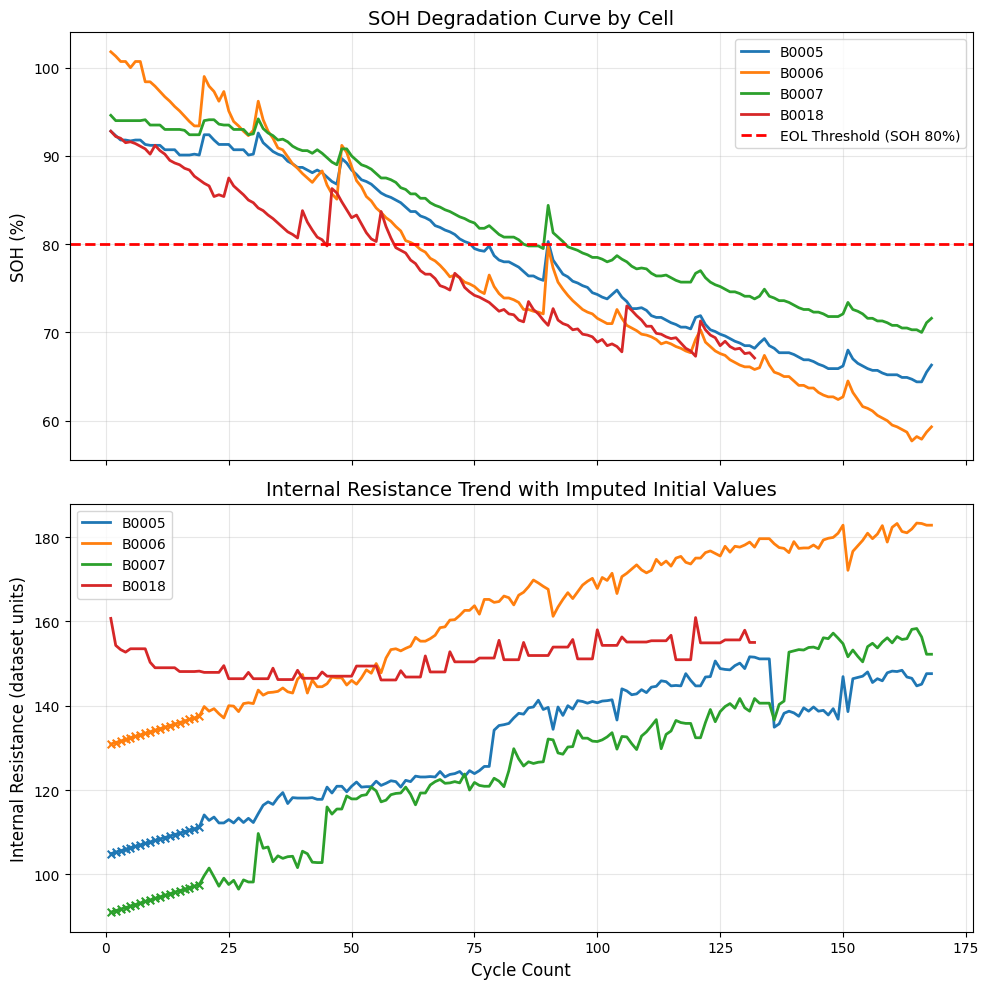

In [165]:
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt

# 캔버스 설정: 위는 SOH, 아래는 내부저항
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 10),
    sharex=True
)

colors = {
    "B0005": "tab:blue",
    "B0006": "tab:orange",
    "B0007": "tab:green",
    "B0018": "tab:red"
}


# 1. 셀별 SOH 열화 곡선
for cell_id, cell_data in nasa.groupby("cell_id"):

    cell_data = cell_data.sort_values("cycle_count")

    ax1.plot(
        cell_data["cycle_count"],
        cell_data["soh"],
        label=cell_id,
        linewidth=2,
        color=colors[cell_id]
    )

# EOL 기준선
ax1.axhline(
    y=80,
    color="red",
    linestyle="--",
    linewidth=2,
    label="EOL Threshold (SOH 80%)"
)

ax1.set_title("SOH Degradation Curve by Cell", fontsize=14)
ax1.set_ylabel("SOH (%)", fontsize=12)
ax1.grid(alpha=0.3)
ax1.legend()


# 2. 셀별 내부저항 변화
for cell_id, cell_data in nasa.groupby("cell_id"):

    cell_data = cell_data.sort_values("cycle_count")

    # 결측값이 보완된 내부저항 곡선
    ax2.plot(
        cell_data["cycle_count"],
        cell_data["internal_resistance_filled"],
        label=cell_id,
        linewidth=2,
        color=colors[cell_id]
    )

    # 추정값만 별도 표시
    imputed_data = cell_data[
        cell_data["ir_imputed"] == 1
    ]

    ax2.scatter(
        imputed_data["cycle_count"],
        imputed_data["internal_resistance_filled"],
        marker="x",
        s=30,
        color=colors[cell_id]
    )

ax2.set_title(
    "Internal Resistance Trend with Imputed Initial Values",
    fontsize=14
)

ax2.set_xlabel("Cycle Count", fontsize=12)
ax2.set_ylabel("Internal Resistance (dataset units)", fontsize=12)
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# 그림을 통해 알 수 있는 점:
# 사이클이 증가할수록 SOH는 전반적으로 감소하고
# 내부저항은 증가하는 반대 방향의 추세가 나타났으며,
# 이는 두 변수 사이의 음의 상관관계 분석 결과를 시각적으로 뒷받침한다.


In [166]:

# ─────────────────────────────────────────────
# [해야 할 일] 각 셀이 몇 번째 사이클에 EOL(SOH 80% 미만)에 도달했는지
# [힌트] EOL 여부를 나타내는 컬럼이 이미 있습니다 (is_eol)
#        그 값이 1인 행만 고른 뒤, 셀별로 묶어서 가장 작은 사이클을 찾으면 됩니다
# [결과] 셀 4개의 EOL 도달 사이클
# ─────────────────────────────────────────────
# is_eol이 1인 행만 선택
eol_rows = nasa[nasa["is_eol"] == 1]

# 셀별 최초 EOL 도달 사이클
eol_cycle = (
    eol_rows.groupby("cell_id")["cycle_count"]
    .min()
)

print("--셀별 최초 EOL 도달 사이클--")
print(eol_cycle)

# ✏️ 가장 빨리 죽은 셀:   B0018   가장 오래 버틴 셀:    B0007
# 차이:   86 - 45 = 41 사이클


--셀별 최초 EOL 도달 사이클--
cell_id
B0005    75
B0006    63
B0007    86
B0018    45
Name: cycle_count, dtype: int64


---
# 관문 ④ · 교차 검증 ★변별
### "PART 1의 발견이 PART 2에서도 성립하나요?"

두 데이터를 따로 분석하고 끝내면 절반입니다. **연결**하세요.

In [167]:
# ─────────────────────────────────────────────
# [해야 할 일] PART 1에서 찾은 열화 신호(변수)가
#              NASA 데이터에서도 같은 방향인지 상관으로 확인
#
# [힌트] 두 데이터 각각에서 해당 변수와 soh의 상관계수를 구해 나란히 출력
# [따져볼 것] 방향(+/-)은 같은가? 강도는? 왜 차이가 날까?
# ─────────────────────────────────────────────
# [해야 할 일] PART 1에서 찾은 열화 신호인 내부저항이
# NASA 데이터에서도 SOH와 같은 음의 방향을 보이는지 확인

# 1. M 데이터: 내부저항과 SOH 상관계수
m_corr = m_clean["internal_resistance"].corr(
    m_clean["soh"]
)

# 2. NASA 데이터: 결측값을 보완한 내부저항과 SOH 상관계수
nasa_corr_filled = nasa["internal_resistance_filled"].corr(
    nasa["soh"]
)

# 참고: 실제 측정값만 사용한 상관계수
nasa_corr_original = nasa["internal_resistance"].corr(
    nasa["soh"]
)

print("M 데이터 상관계수:", round(m_corr, 2))
print(
    "NASA 데이터 상관계수 (실측값만):",
    round(nasa_corr_original, 2)
)
print(
    "NASA 데이터 상관계수 (결측 보완 후):",
    round(nasa_corr_filled, 2)
)


# 3. NASA 데이터의 셀별 내부저항-SOH 상관계수
cell_corr_filled = {}

for cell_id, cell_data in nasa.groupby("cell_id"):

    corr = cell_data["internal_resistance_filled"].corr(
        cell_data["soh"]
    )

    cell_corr_filled[cell_id] = corr

cell_corr_filled = pd.Series(
    cell_corr_filled,
    name="internal_resistance_soh_corr"
)

print("\nNASA 셀별 내부저항-SOH 상관계수")
print(cell_corr_filled.round(2))



# ✏️ M 데이터 상관: -0.84
# ✏️ NASA 데이터 상관: -0.73

# ✏️ 나의 해석:
# 두 데이터에서 모두 내부저항과 SOH 사이에 강한 음의 상관관계가 나타났다.
# 즉, 내부저항이 증가할수록 SOH가 감소하는 동일한 방향이 확인되었다.
# 따라서 내부저항은 서로 다른 데이터에서도 공통적으로 확인되는
# 일관된 배터리 열화 신호라고 해석할 수 있다.

# 두 상관계수의 차이가 발생한 이유:
# 1. 데이터의 구조적 차이: M 데이터는 특정 시점에 여러 배터리를 측정한 단면 데이터이다.
# 따라서 상관계수가 셀 간의 편차를 반영한다.
# 반면 NASA 데이터는 시계열 데이터이므로, 셀 내부의
# 시간적 열화 추세를 반영한다.
# 평가 기준과 분산의 성격이 다르기 때문에 두 상관관계 사이
# 편차가 발생한다.
#
# 2. 두 데이터의 SOH 계산 기준이 다르다.
#    M: current_capacity / initial_capacity × 100
#    NASA: capacity / 2.0 Ah × 100
#    따라서 SOH 값이 동일한 기준으로 계산된 것은 아니다.
#
# 3. M 데이터에서는 평균 온도와 SOH가 약한 음의 상관을 보여,
#    온도와 같은 운용조건도 열화에 일부 영향을 미쳤을 가능성이 있다.
#
# 4. 데이터에 없는 내부저항 측정 방식, C-rate, 방전 깊이,
#    종료전압 등의 차이도 상관계수에 영향을 줄 수 있다.

M 데이터 상관계수: -0.84
NASA 데이터 상관계수 (실측값만): -0.71
NASA 데이터 상관계수 (결측 보완 후): -0.73

NASA 셀별 내부저항-SOH 상관계수
B0005   -0.94
B0006   -0.99
B0007   -0.97
B0018   -0.56
Name: internal_resistance_soh_corr, dtype: float64


In [168]:
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별로 나눠서 본 상관 vs 전체를 한 덩어리로 본 상관 ★
# [힌트] groupby로 셀을 나눈 뒤, 각 그룹에서 저항-SOH 상관을 구해 비교
# [따져볼 것] 셀마다 값이 크게 다른가? 전체 상관과 차이가 나는가?
#             다르다면 "평균의 함정"일 수 있습니다
# ─────────────────────────────────────────────
# 전체 데이터를 한 덩어리로 계산한 상관계수
overall_corr = nasa["internal_resistance_filled"].corr(nasa["soh"])

print("전체 내부저항-SOH 상관:", round(overall_corr, 2))

# 셀별 내부저항-SOH 상관계수
cell_corr = {}

for cell_id, cell_data in nasa.groupby("cell_id"):
  corr = cell_data["internal_resistance_filled"].corr(cell_data["soh"])
  cell_corr[cell_id] = corr

cell_corr = pd.Series(
    cell_corr,
    name="resistance_soh_corr"
)

print("셀별 내부저항-SOH 상관")
print(cell_corr.round(2))
# ─────────────────────────────────────────────
# [해야 할 일 · 심화] 셀별 열화 속도(기울기) 비교
# [힌트] (첫 SOH - 마지막 SOH) / 사이클 수, 또는 numpy polyfit으로 직선 맞추기
# ─────────────────────────────────────────────
import numpy as np

slope_result = {}

for cell_id, cell_data in nasa.groupby("cell_id"):

  #사이클 순서대로 정렬
  cell_data = cell_data.sort_values("cycle_count")

  #SOH = 기울기 * cycle_count + 절편
  slope, intercept = np.polyfit(
      cell_data["cycle_count"],
      cell_data["soh"],
      1
  )

  slope_result[cell_id] = slope

slope_result = pd.Series(
    slope_result,
    name = "soh_slope"
)

print("셀별 SOH 기울기:")
print(slope_result.round(3))


전체 내부저항-SOH 상관: -0.73
셀별 내부저항-SOH 상관
B0005   -0.94
B0006   -0.99
B0007   -0.97
B0018   -0.56
Name: resistance_soh_corr, dtype: float64
셀별 SOH 기울기:
B0005   -0.193
B0006   -0.254
B0007   -0.164
B0018   -0.196
Name: soh_slope, dtype: float64


---
# 4단계 · 결론·한계 메모
발표 9~10장에 쓸 내용을 여기에 정리하세요.

In [170]:
결론 = """
M 데이터에서 현재용량은 SOH 계산에 직접 포함된 변수이므로
상관계수가 높더라도 독립적인 열화 원인으로 보기 어려웠다.

이를 제외하면 내부저항이 SOH와 가장 강한 물리적 관계를 보였으며
M 데이터에서는 -0.84, NASA 데이터에서는 -0.72의
음의 상관관계가 확인되었다.

또한 NASA 데이터에서 셀별 EOL은 45~86사이클로 차이가 났으며,
초기 SOH와 내부저항 수준, SOH 감소 속도가 셀 수명 차이에
함께 영향을 준 것으로 해석하였다.

따라서 내부저항은 열화의 단일 원인이라기보다는,
배터리 내부 상태를 반영하는 핵심 진단 신호라고 할 수 있다.

"""

한계_3가지 = """
1. 측정조건의 한계
내부저항의 측정 방식, SOC, 온도 등
구체적인 시험조건을 알 수 없다.

2. 데이터 구조의 차이
M은 30개 셀의 스냅샷, NASA는 4개 셀의 반복 시계열로
상관계수의 크기를 직접 비교하기 어렵다.

3. 물리화학적 정보의 한계
전극·전해질 조성과 제조 이력이 없어
내부저항 증가의 구체적인 열화 메커니즘을 판별할 수 없다.
"""

print(결론); print(한계_3가지)


M 데이터에서 현재용량은 SOH 계산에 직접 포함된 변수이므로
상관계수가 높더라도 독립적인 열화 원인으로 보기 어려웠다.

이를 제외하면 내부저항이 SOH와 가장 강한 물리적 관계를 보였으며
M 데이터에서는 -0.84, NASA 데이터에서는 -0.72의
음의 상관관계가 확인되었다.

또한 NASA 데이터에서 셀별 EOL은 45~86사이클로 차이가 났으며,
초기 SOH와 내부저항 수준, SOH 감소 속도가 셀 수명 차이에
함께 영향을 준 것으로 해석하였다.

따라서 내부저항은 열화의 단일 원인이라기보다는,
배터리 내부 상태를 반영하는 핵심 진단 신호라고 할 수 있다.



1. 측정조건의 한계
내부저항의 측정 방식, SOC, 온도 등
구체적인 시험조건을 알 수 없다.

2. 데이터 구조의 차이
M은 30개 셀의 스냅샷, NASA는 4개 셀의 반복 시계열로
상관계수의 크기를 직접 비교하기 어렵다.

3. 물리화학적 정보의 한계
전극·전해질 조성과 제조 이력이 없어
내부저항 증가의 구체적인 열화 메커니즘을 판별할 수 없다.



---
## 제출 전 확인

- [ ] **런타임 → 모두 실행** 후 저장 (실행 결과가 남아 있어야 합니다)
- [ ] 필수 재현 ②의 셀 수가 Orange3 결과와 일치
- [ ] 열화 곡선 그래프가 그려졌다
- [ ] 관문 ①~④ 중 시도한 것에 ✏️ 메모를 채웠다
- [ ] 파일명이 `미션재현_이름.ipynb`

> **제출 마감: 23:00** — 파일 → 다운로드 → `.ipynb` 다운로드 후 안내 채널에 업로드

> 완성하지 못한 관문이 있어도 괜찮습니다. **시도한 흔적(코드와 메모)이 남아 있으면 부분 점수**를 받습니다.